<a href="https://colab.research.google.com/github/SithuminiNimthara/Research_Project/blob/main/shorelin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics opencv-python-headless pandas matplotlib tqdm pyyaml --quiet


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.5 MB/s eta 0:00:00


In [2]:
import os, glob

zip_path = "/content/drive/MyDrive/Research/shoreline_seg_dataset.zip"

!mkdir -p /content/datasets
!unzip -q "{zip_path}" -d /content/datasets

!find /content/datasets -maxdepth 5 -name "data.yaml" -print


/content/datasets/data.yaml


In [3]:
data_yaml = "/content/datasets/data.yaml"  # <-- update if needed
run_name  = "shoreline_seg_v1"

if not os.path.exists(data_yaml):
    raise FileNotFoundError(f"❌ data.yaml not found: {data_yaml}")
print("✅ Found data.yaml:", data_yaml)


✅ Found data.yaml: /content/datasets/data.yaml


In [4]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")  # fast baseline

model.train(
    data=data_yaml,
    epochs=80,
    imgsz=640,
    batch=16,
    name=run_name
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bebe8188530>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [5]:
import os

run_dir = f"/content/runs/segment/{run_name}"
best_pt = run_dir + "/weights/best.pt"

if not os.path.exists(best_pt):
    raise FileNotFoundError(f"❌ best.pt not found: {best_pt}")

save_pt = "/content/drive/MyDrive/Research/shoreline_seg_best.pt"
!cp "{best_pt}" "{save_pt}"

print("✅ Best model saved to Drive:", save_pt)
print("Run dir:", run_dir)


✅ Best model saved to Drive: /content/drive/MyDrive/Research/shoreline_seg_best.pt
Run dir: /content/runs/segment/shoreline_seg_v1


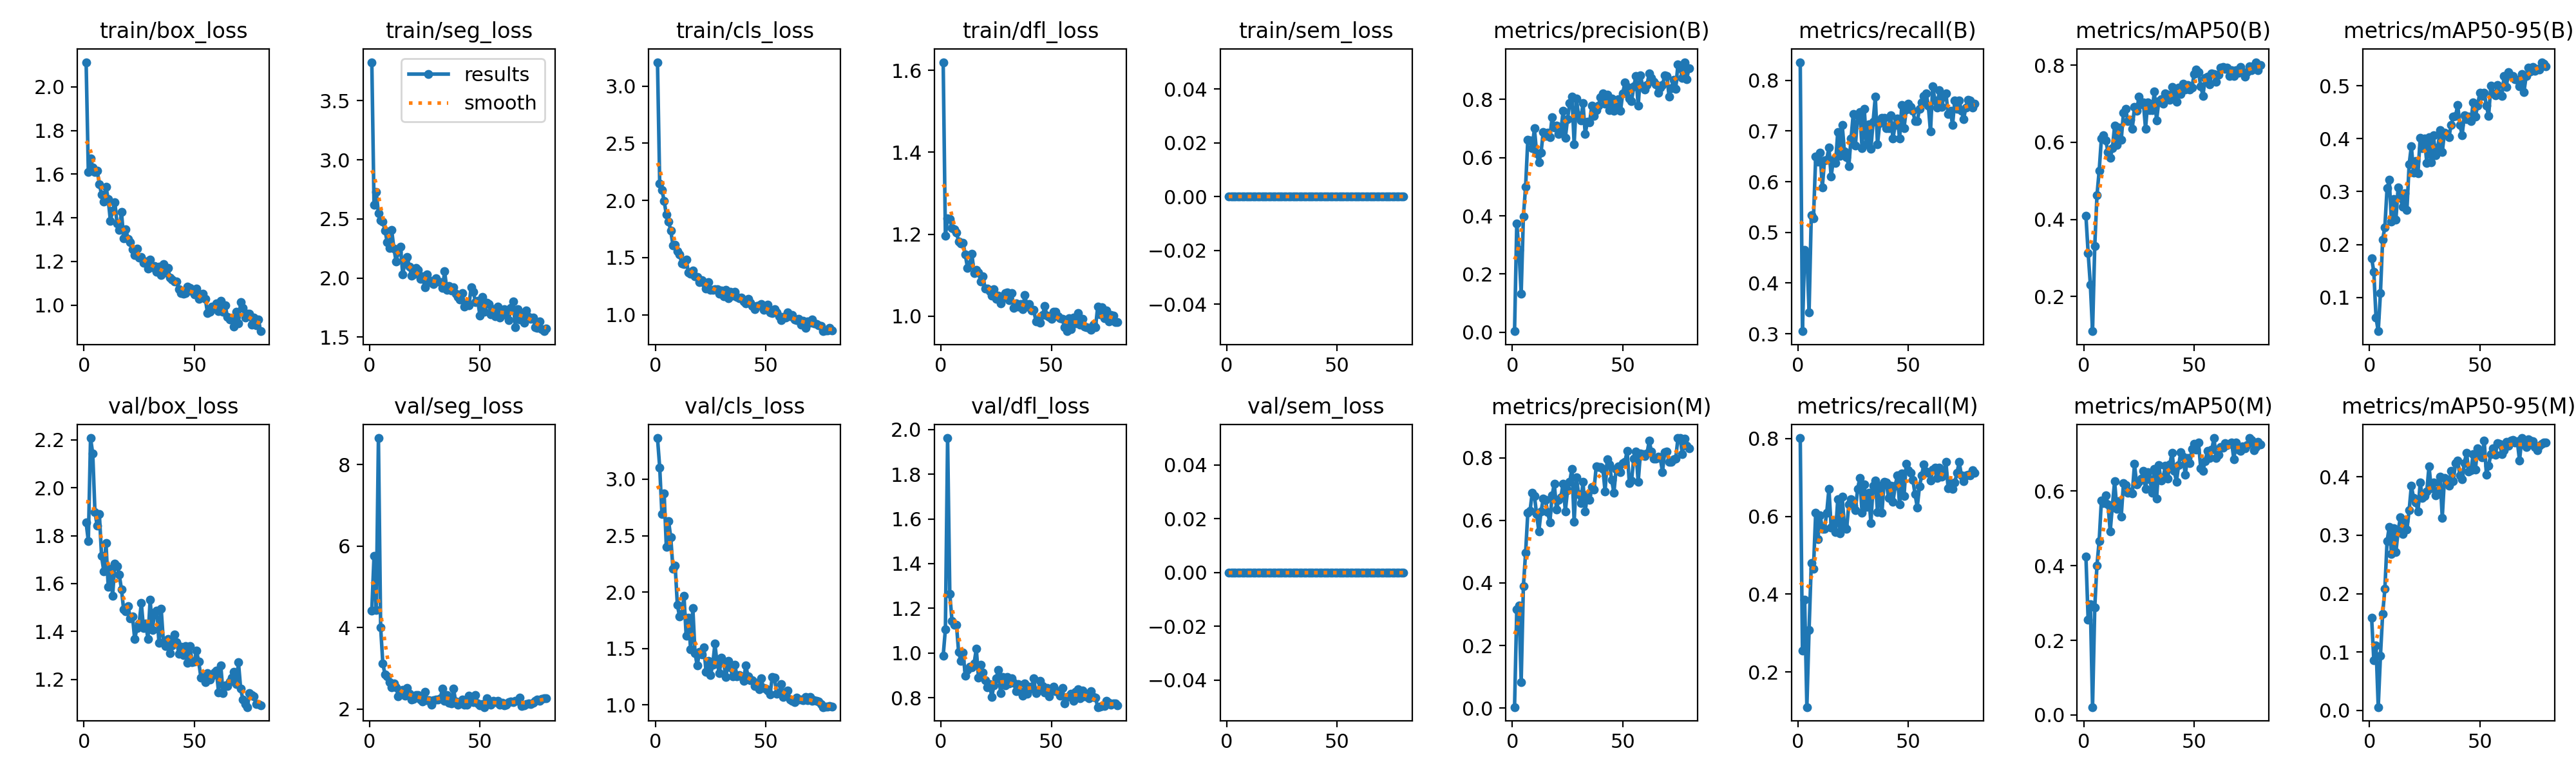

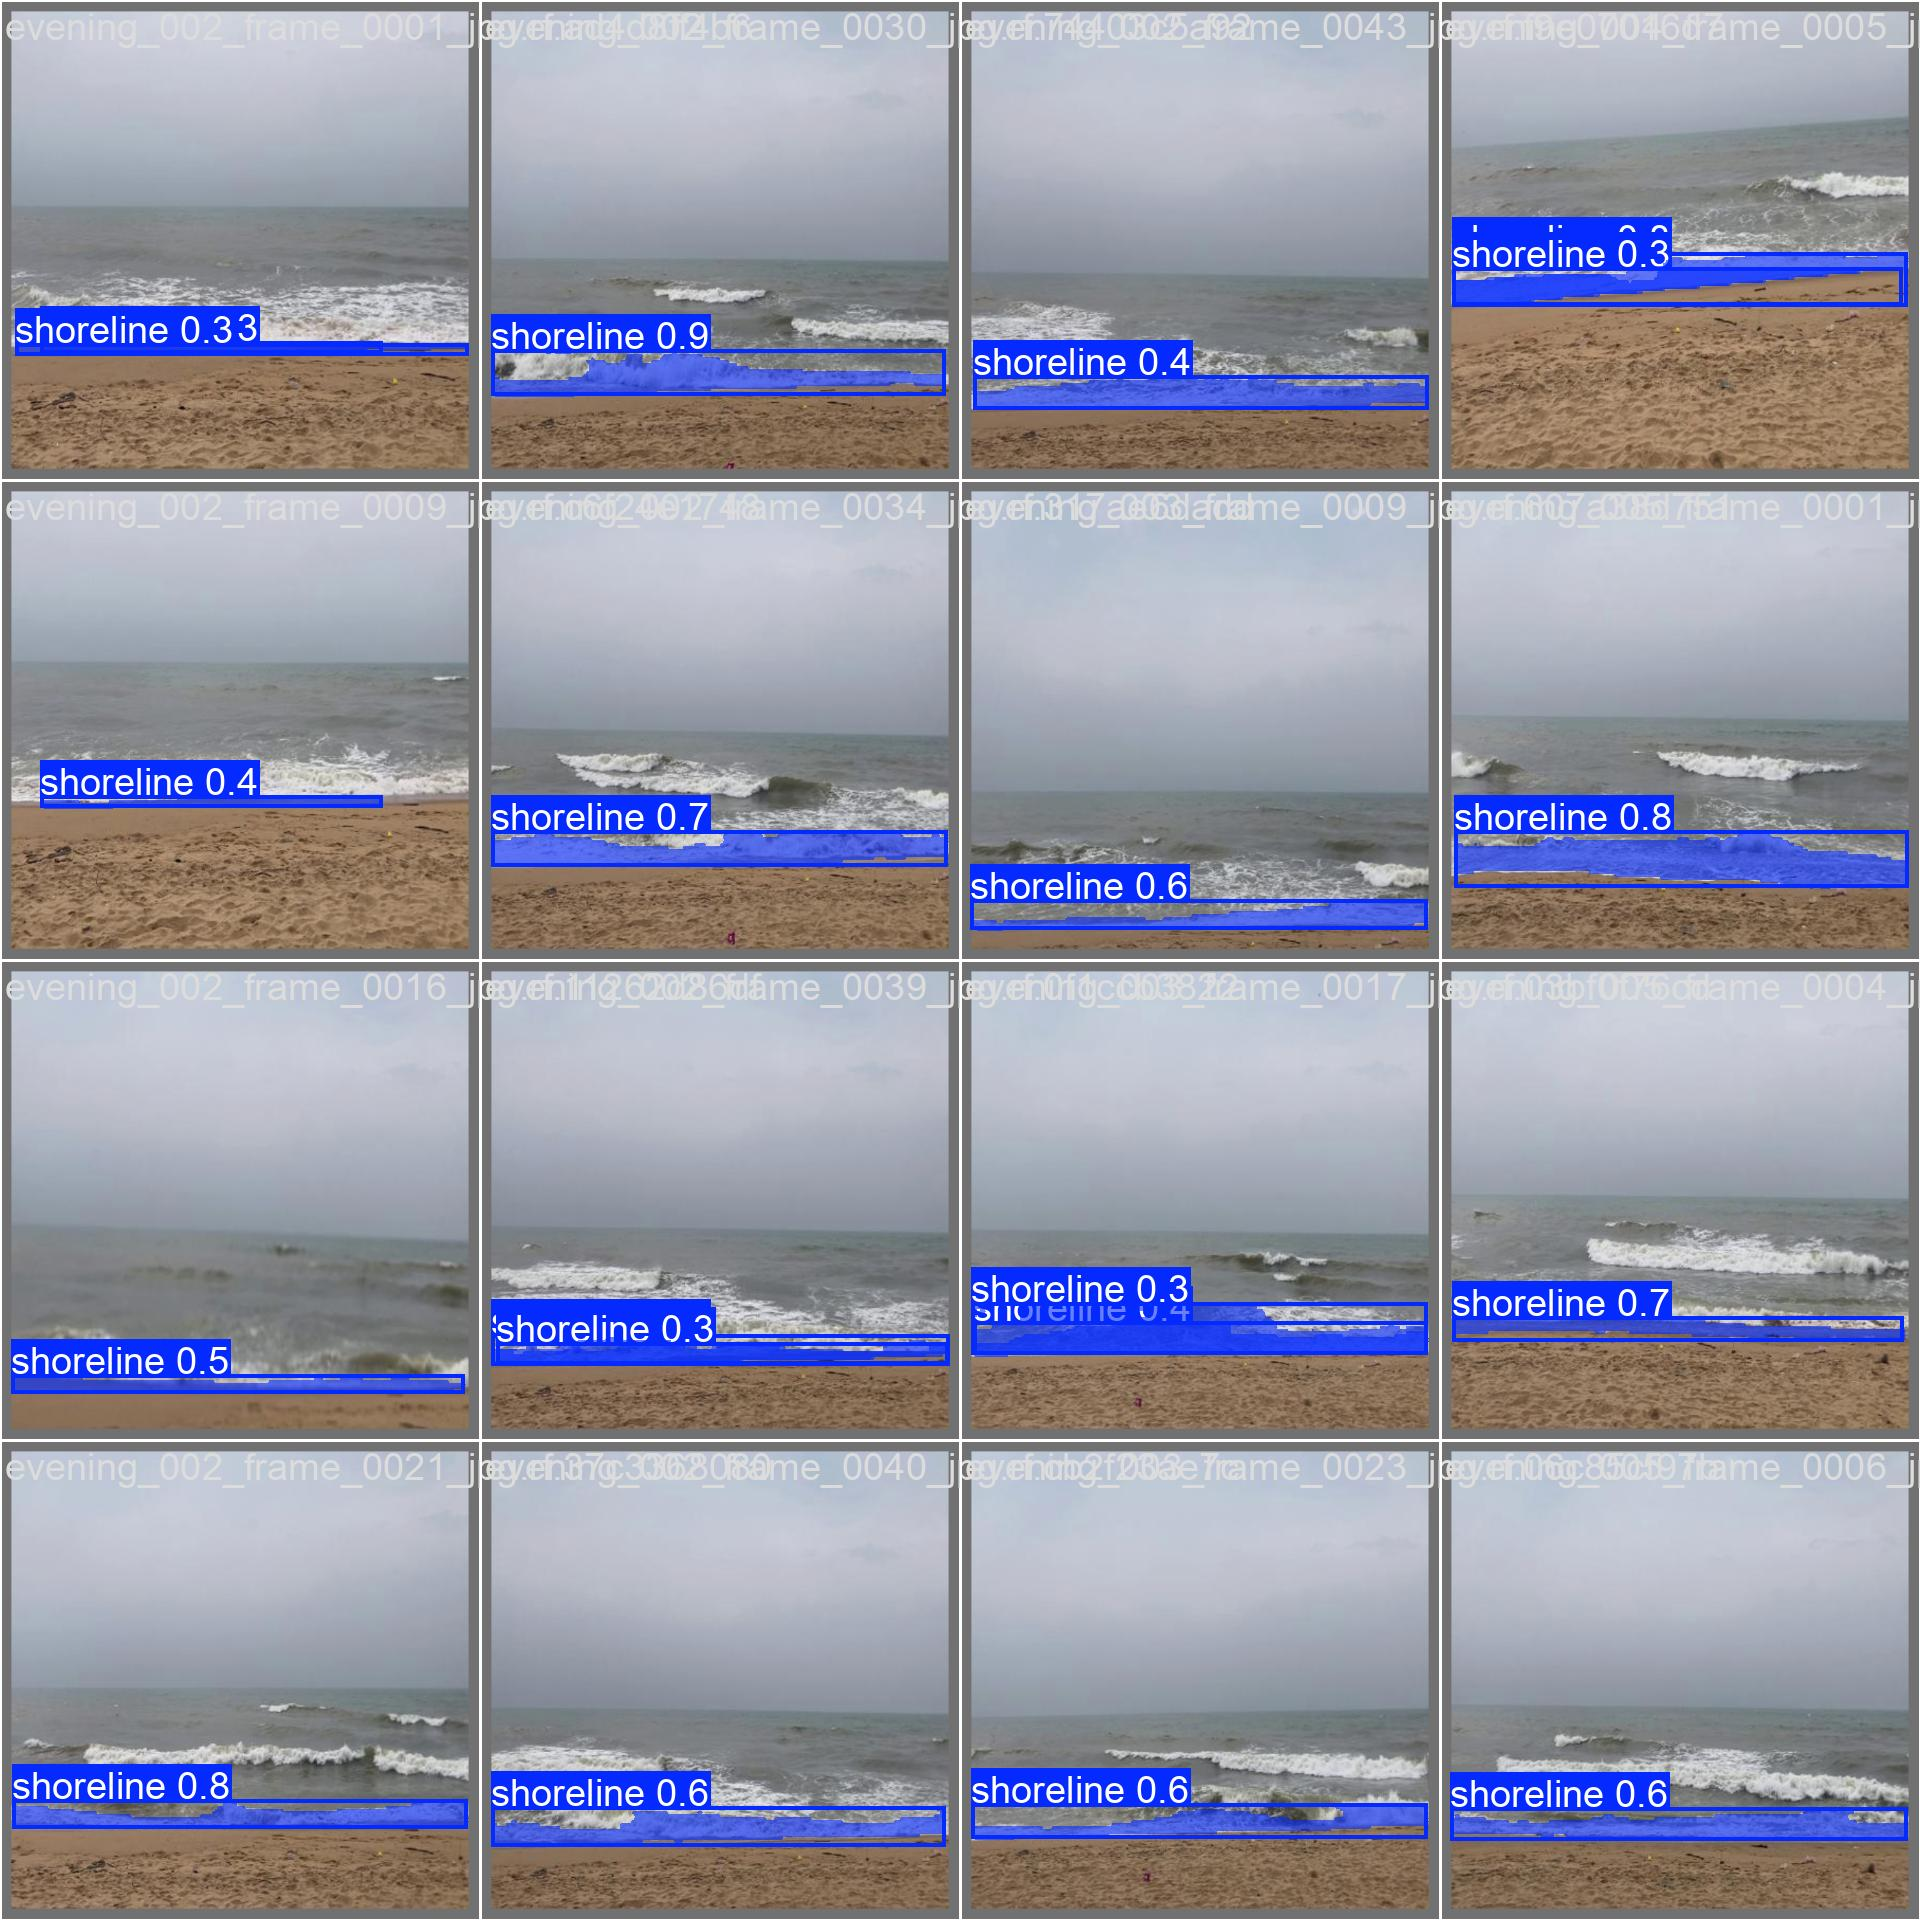

In [6]:
from IPython.display import Image, display
display(Image(run_dir + "/results.png"))
display(Image(run_dir + "/val_batch0_pred.jpg"))


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = run_dir + "/results.csv"
df = pd.read_csv(csv_path)
print("✅ Columns:", df.columns.tolist())
df.head()


✅ Columns: ['epoch', 'time', 'train/box_loss', 'train/seg_loss', 'train/cls_loss', 'train/dfl_loss', 'train/sem_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(M)', 'metrics/recall(M)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)', 'val/box_loss', 'val/seg_loss', 'val/cls_loss', 'val/dfl_loss', 'val/sem_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


,epoch,time,train/box_loss,train/seg_loss,train/cls_loss,train/dfl_loss,train/sem_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),...,metrics/mAP50(M),metrics/mAP50-95(M),val/box_loss,val/seg_loss,val/cls_loss,val/dfl_loss,val/sem_loss,lr/pg0,lr/pg1,lr/pg2
0,1,16.3129,2.11307,3.82502,3.20848,1.62015,0,0.00325,0.83562,0.40938,...,0.42462,0.15899,1.85443,4.41623,3.36492,0.98743,0,0.000540,0.000540,0.000540
1,2,28.5464,1.61145,2.62013,2.14631,1.19676,0,0.37258,0.30506,0.31303,...,0.25554,0.08523,1.77669,5.76255,3.10530,1.10659,0,0.001086,0.001086,0.001086
2,3,42.4369,1.67286,2.72866,2.09173,1.23839,0,0.28206,0.46552,0.23089,...,0.29682,0.11062,2.20703,4.43531,2.69284,1.96160,0,0.001619,0.001619,0.001619
3,4,54.7817,1.63017,2.54802,1.99654,1.23660,0,0.13260,0.45890,0.10972,...,0.02104,0.00553,2.14189,8.65231,2.87670,1.26399,0,0.001926,0.001926,0.001926
4,5,67.1795,1.61120,2.49054,1.87575,1.21570,0,0.39713,0.34247,0.33075,...,0.28841,0.09311,1.89843,4.00592,2.40203,1.14305,0,0.001901,0.001901,0.001901


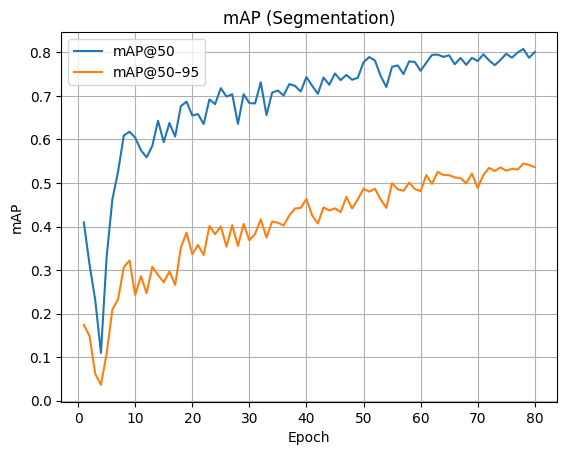

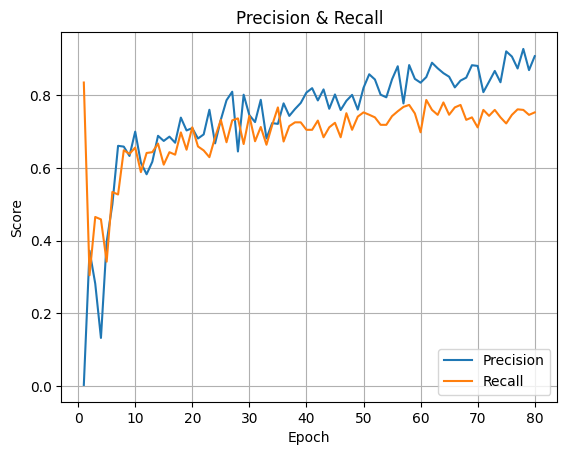

In [8]:
plt.figure()
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@50–95")
plt.xlabel("Epoch"); plt.ylabel("mAP"); plt.title("mAP (Segmentation)")
plt.legend(); plt.grid(); plt.show()

plt.figure()
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.xlabel("Epoch"); plt.ylabel("Score"); plt.title("Precision & Recall")
plt.legend(); plt.grid(); plt.show()


In [18]:
import glob, os
import pandas as pd
import numpy as np

test_folder = "/content/drive/MyDrive/Research/test_frames"
imgs = sorted(glob.glob(test_folder + "/*.jpg"))

rows = []
for p in imgs:
    rows.append({
        "image": os.path.basename(p),
        "nest_id": "N1",
        "x": np.nan,   # ✅ NaN
        "y": np.nan    # ✅ NaN
    })

nests_df = pd.DataFrame(rows)
out = "/content/drive/MyDrive/Research/nest_points.csv"
nests_df.to_csv(out, index=False)

print("✅ Created template CSV:", out)
nests_df.head(10)


✅ Created template CSV: /content/drive/MyDrive/Research/nest_points.csv


,image,nest_id,x,y
0,lowtide_004_frame_0000.jpg,N1,NaN,NaN


In [36]:
import pandas as pd

csv_path = "/content/drive/MyDrive/Research/nest_points.csv"
df = pd.read_csv(csv_path)

# 👉 Replace with YOUR real coordinate
FIXED_X = 1000
FIXED_Y = 850

df["x"] = FIXED_X
df["y"] = FIXED_Y

df.to_csv(csv_path, index=False)

print("✅ All rows filled with fixed nest location")
df.head()


✅ All rows filled with fixed nest location


,image,nest_id,x,y
0,lowtide_004_frame_0000.jpg,N1,1000,850
1,morning_007_frame_0038.jpg,N1,1000,850
2,morning_007_frame_0026.jpg,N1,1000,850
3,morning_001_frame_0009.jpg,N1,1000,850


In [37]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Research/nest_points.csv")

print(df.head())
print("Unique X:", df["x"].unique())
print("Unique Y:", df["y"].unique())


                        image nest_id     x    y
0  lowtide_004_frame_0000.jpg      N1  1000  850
1  morning_007_frame_0038.jpg      N1  1000  850
2  morning_007_frame_0026.jpg      N1  1000  850
3  morning_001_frame_0009.jpg      N1  1000  850
Unique X: [1000]
Unique Y: [850]


In [38]:
from ultralytics import YOLO
import cv2
import numpy as np

save_pt = "/content/drive/MyDrive/Research/shoreline_seg_best.pt"  # your saved model
model = YOLO(save_pt)

print("✅ Model loaded:", save_pt)


✅ Model loaded: /content/drive/MyDrive/Research/shoreline_seg_best.pt


In [39]:
def get_biggest_mask(results, img_shape):
    if results.masks is None:
        return None

    masks = results.masks.data.cpu().numpy()  # (n,H,W)
    areas = [m.sum() for m in masks]
    m = masks[int(np.argmax(areas))]

    mask_bin = (m * 255).astype(np.uint8)
    mask_bin = cv2.resize(mask_bin, (img_shape[1], img_shape[0]))
    _, mask_bin = cv2.threshold(mask_bin, 127, 255, cv2.THRESH_BINARY)
    return mask_bin

def clean_mask(mask_bin):
    kernel = np.ones((7,7), np.uint8)
    mask_bin = cv2.morphologyEx(mask_bin, cv2.MORPH_CLOSE, kernel)
    mask_bin = cv2.morphologyEx(mask_bin, cv2.MORPH_OPEN, kernel)
    return mask_bin

def contour_distance(mask_bin, nest_pt):
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return None, None

    shore_contour = max(contours, key=cv2.contourArea)
    pts = shore_contour.reshape(-1, 2)

    nx, ny = nest_pt
    dx = pts[:, 0] - nx
    dy = pts[:, 1] - ny
    dists = np.sqrt(dx*dx + dy*dy)

    min_idx = int(np.argmin(dists))
    closest_pt = (int(pts[min_idx, 0]), int(pts[min_idx, 1]))
    min_dist = float(dists[min_idx])
    return min_dist, closest_pt

def risk_label(dist_m, safe_th=2.0, warn_th=1.0):
    if dist_m > safe_th:
        return "SAFE"
    elif dist_m >= warn_th:
        return "WARNING"
    else:
        return "DANGER"



0: 384x640 1 shoreline, 12.1ms
Speed: 2.6ms preprocess, 12.1ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)
Nest: (1000, 850)
Closest shoreline: (1000, 885)
Dist(px): 35.0
Dist(m): 0.29
Risk: DANGER


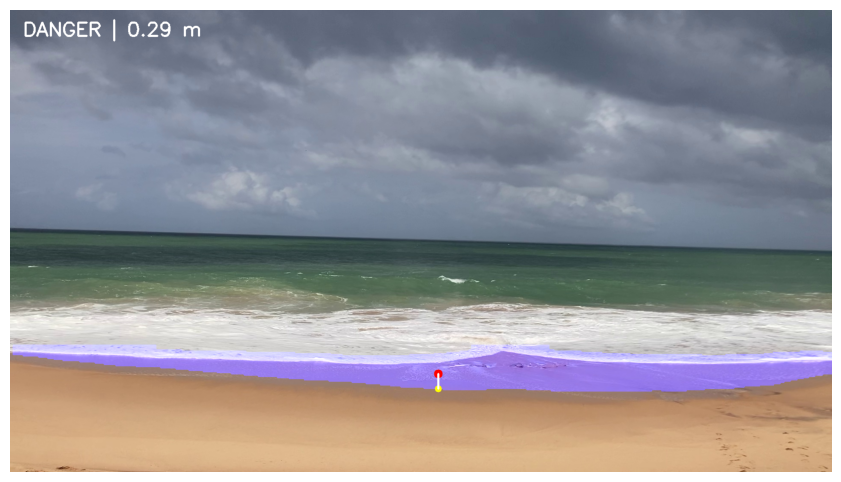

In [40]:
import os
import matplotlib.pyplot as plt

test_img_path = "/content/drive/MyDrive/Research/test_frames/morning_001_frame_0009.jpg"
img_name = os.path.basename(test_img_path)

# fixed nest (from CSV first row; all same)
nest_x = int(df.iloc[0]["x"])
nest_y = int(df.iloc[0]["y"])
nest_pt = (nest_x, nest_y)

img = cv2.imread(test_img_path)
res = model(img)[0]

mask_bin = get_biggest_mask(res, img.shape)
if mask_bin is None:
    raise ValueError("❌ No mask predicted")

mask_bin = clean_mask(mask_bin)

PX_PER_METER = 120  # temporary calibration
min_dist_px, closest_pt = contour_distance(mask_bin, nest_pt)
if min_dist_px is None:
    raise ValueError("❌ No contour found")

dist_m = min_dist_px / PX_PER_METER
risk = risk_label(dist_m)

print("Nest:", nest_pt)
print("Closest shoreline:", closest_pt)
print("Dist(px):", round(min_dist_px, 2))
print("Dist(m):", round(dist_m, 2))
print("Risk:", risk)

# overlay
overlay = img.copy()
blue = np.zeros_like(img)
blue[:, :, 0] = mask_bin
overlay = cv2.addWeighted(overlay, 1.0, blue, 0.5, 0)

cv2.circle(overlay, nest_pt, 10, (0, 0, 255), -1)
cv2.circle(overlay, closest_pt, 8, (0, 255, 255), -1)
cv2.line(overlay, nest_pt, closest_pt, (255, 255, 255), 3)

txt = f"{risk} | {dist_m:.2f} m"
cv2.putText(overlay, txt, (30, 60),
            cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 255), 3)

plt.figure(figsize=(14,6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [41]:
out_path = "/content/drive/MyDrive/Research/risk_overlay_seg9.png"
cv2.imwrite(out_path, overlay)
print("✅ Saved:", out_path)


✅ Saved: /content/drive/MyDrive/Research/risk_overlay_seg9.png


In [43]:
import glob
from tqdm import tqdm
import pandas as pd

test_folder = "/content/drive/MyDrive/Research/test_frames"
images = sorted(glob.glob(test_folder + "/*.jpg"))

PX_PER_METER = 120  # temporary
rows = []

nest_x = int(df.iloc[0]["x"])
nest_y = int(df.iloc[0]["y"])
nest_pt = (nest_x, nest_y)

for img_path in tqdm(images):
    name = os.path.basename(img_path)

    img = cv2.imread(img_path)
    res = model(img)[0]

    mask_bin = get_biggest_mask(res, img.shape)
    if mask_bin is None:
        continue

    mask_bin = clean_mask(mask_bin)

    dpx, closest = contour_distance(mask_bin, nest_pt)
    if dpx is None:
        continue

    dm = dpx / PX_PER_METER
    risk = risk_label(dm)

    rows.append({
        "image": name,
        "nest_x": nest_x, "nest_y": nest_y,
        "min_dist_px": dpx,
        "dist_m": dm,
        "risk": risk
    })

eval_df = pd.DataFrame(rows)
out_csv = "/content/drive/MyDrive/Research/shoreline_risk_eval.csv"
eval_df.to_csv(out_csv, index=False)

print("✅ Saved evaluation CSV:", out_csv)
eval_df.head()

  0%|          | 0/6 [00:00<?, ?it/s]


0: 384x640 1 shoreline, 16.9ms
Speed: 4.9ms preprocess, 16.9ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 shoreline, 11.3ms
Speed: 4.2ms preprocess, 11.3ms inference, 3.3ms postprocess per image at shape (1, 3, 384, 640)


 33%|███▎      | 2/6 [00:00<00:00, 15.64it/s]


0: 384x640 2 shorelines, 18.2ms
Speed: 3.2ms preprocess, 18.2ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 shoreline, 8.9ms
Speed: 3.2ms preprocess, 8.9ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)


 67%|██████▋   | 4/6 [00:02<00:01,  1.47it/s]


0: 384x640 1 shoreline, 8.9ms
Speed: 3.1ms preprocess, 8.9ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 shoreline, 9.9ms
Speed: 3.4ms preprocess, 9.9ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)


100%|██████████| 6/6 [00:03<00:00,  1.85it/s]

✅ Saved evaluation CSV: /content/drive/MyDrive/Research/shoreline_risk_eval.csv


,image,nest_x,nest_y,min_dist_px,dist_m,risk
0,lowtide_004_frame_0000.jpg,1000,850,221.000000,1.841667,WARNING
1,morning_001_frame_0009.jpg,1000,850,35.000000,0.291667,DANGER
2,morning_007_frame_0026.jpg,1000,850,270.351623,2.252930,SAFE
3,morning_007_frame_0027.jpg,1000,850,294.932196,2.457768,SAFE
4,morning_007_frame_0038.jpg,1000,850,332.776201,2.773135,SAFE


risk
SAFE       4
WARNING    1
DANGER     1
Name: count, dtype: int64


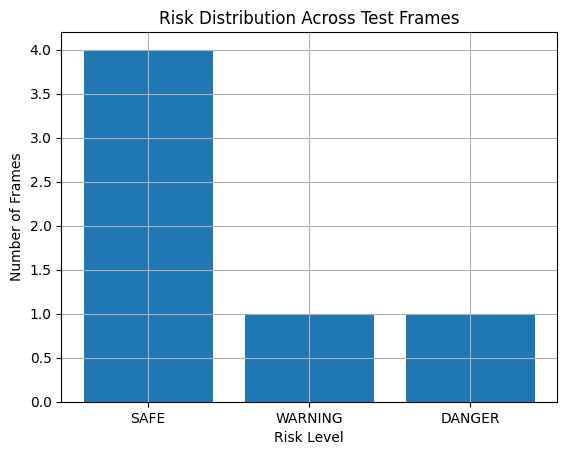

In [44]:
import matplotlib.pyplot as plt

counts = eval_df["risk"].value_counts()
print(counts)

plt.figure()
plt.bar(counts.index, counts.values)
plt.xlabel("Risk Level")
plt.ylabel("Number of Frames")
plt.title("Risk Distribution Across Test Frames")
plt.grid(True)
plt.show()
